In [ ]:
print("="*70)
print("EMPLOYEE ATTRITION PREDICTION USING MACHINE LEARNING")
print("="*70)

print("""
Objective:
The aim of this project is to analyse employee data and build a machine
learning model that predicts whether an employee is likely to leave
the company or not based on different HR-related factors.
""")

EMPLOYEE ATTRITION PREDICTION USING MACHINE LEARNING

Objective:
The aim of this project is to analyse employee data and build a machine
learning model that predicts whether an employee is likely to leave
the company or not based on different HR-related factors.



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve)


In [ ]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("\nDataset loaded successfully.")


Dataset loaded successfully.


In [ ]:
print("\n" + "="*70)
print("FIRST FIVE RECORDS")
print("="*70)

print(df.head())

print("\n" + "="*70)
print("LAST FIVE RECORDS")
print("="*70)

print(df.tail())


FIRST FIVE RECORDS
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockO

In [ ]:
print("\n" + "="*70)
print("DATASET SHAPE")
print("="*70)

rows, columns = df.shape

print(f"Total Rows    : {rows}")
print(f"Total Columns : {columns}")


DATASET SHAPE
Total Rows    : 1470
Total Columns : 35


In [ ]:
print("\n" + "="*70)
print("COLUMN NAMES")
print("="*70)

for column in df.columns:
    print(column)


COLUMN NAMES
Age
Attrition
BusinessTravel
DailyRate
Department
DistanceFromHome
Education
EducationField
EmployeeCount
EmployeeNumber
EnvironmentSatisfaction
Gender
HourlyRate
JobInvolvement
JobLevel
JobRole
JobSatisfaction
MaritalStatus
MonthlyIncome
MonthlyRate
NumCompaniesWorked
Over18
OverTime
PercentSalaryHike
PerformanceRating
RelationshipSatisfaction
StandardHours
StockOptionLevel
TotalWorkingYears
TrainingTimesLastYear
WorkLifeBalance
YearsAtCompany
YearsInCurrentRole
YearsSinceLastPromotion
YearsWithCurrManager


In [ ]:
print("\n" + "="*70)
print("DATASET INFORMATION")
print("="*70)

df.info()


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  Job

In [ ]:
print("\n" + "="*70)
print("STATISTICAL SUMMARY")
print("="*70)

display(df.describe(include="all"))


STATISTICAL SUMMARY


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


In [ ]:
print("\n" + "="*70)
print("MISSING VALUES")
print("="*70)

missing_values = df.isnull().sum()

print(missing_values)


MISSING VALUES
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole      

In [ ]:
print("\n" + "="*70)
print("DUPLICATE RECORDS")
print("="*70)

duplicates = df.duplicated().sum()

print("Total Duplicate Records :", duplicates)


DUPLICATE RECORDS
Total Duplicate Records : 0


In [ ]:
print("\n" + "="*70)
print("BASIC DATASET DETAILS")
print("="*70)

print("Number of Employees :", len(df))

print("Number of Features :", len(df.columns))

print("Target Column : Attrition")


BASIC DATASET DETAILS
Number of Employees : 1470
Number of Features : 35
Target Column : Attrition


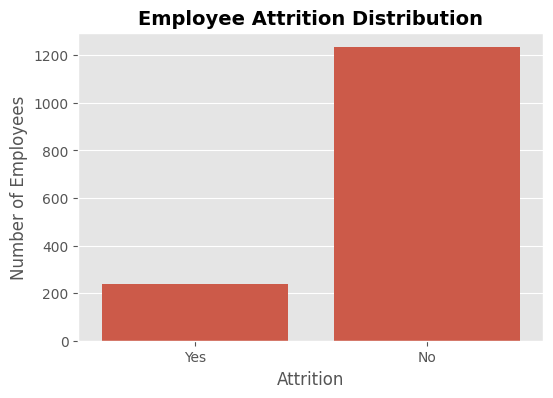

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

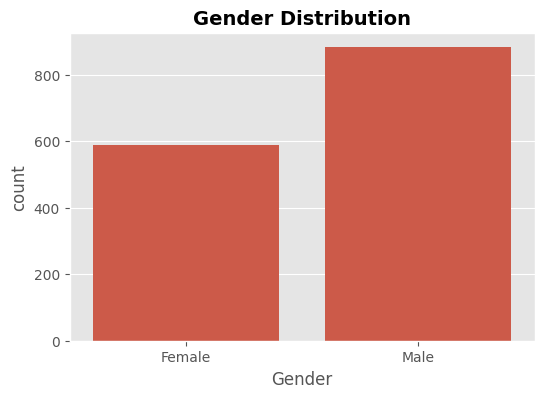

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Distribution",
          fontsize=14,
          fontweight="bold")

plt.show()

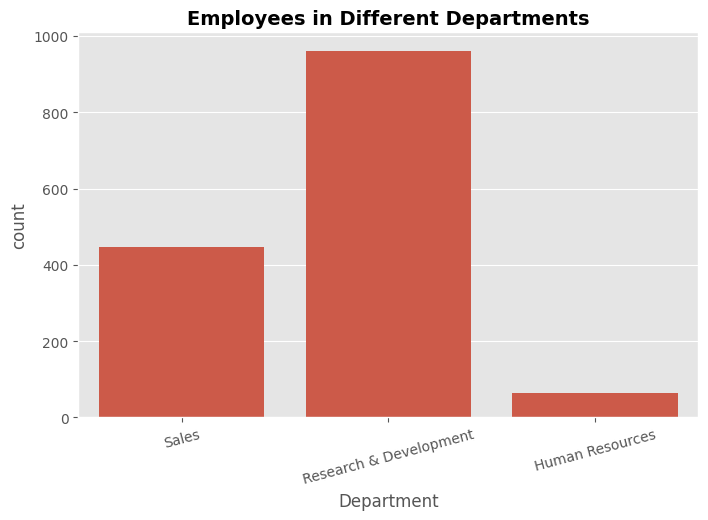

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department"
)

plt.title("Employees in Different Departments",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=15)

plt.show()

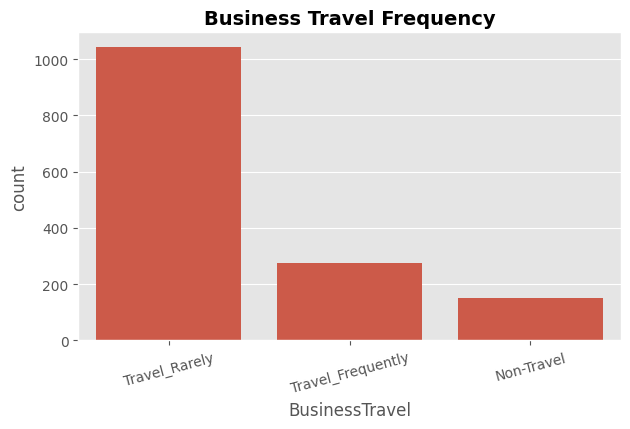

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="BusinessTravel"
)

plt.title("Business Travel Frequency",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=15)

plt.show()

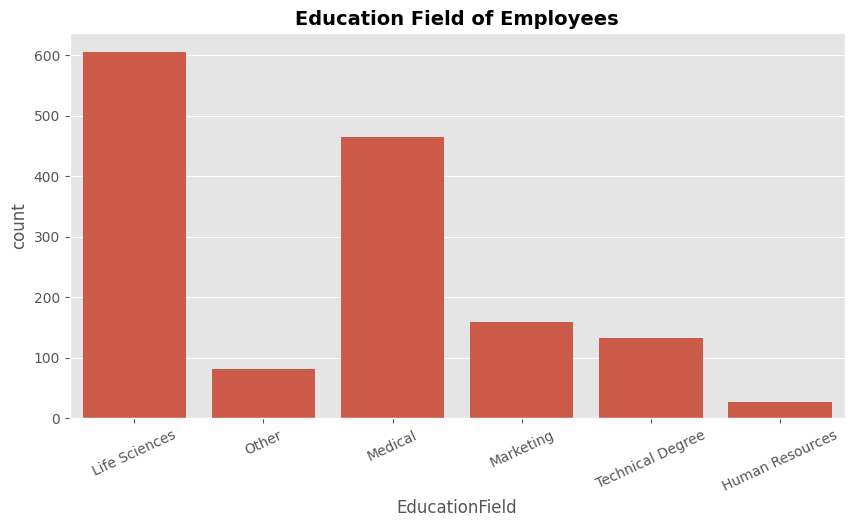

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="EducationField"
)

plt.title("Education Field of Employees",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=25)

plt.show()

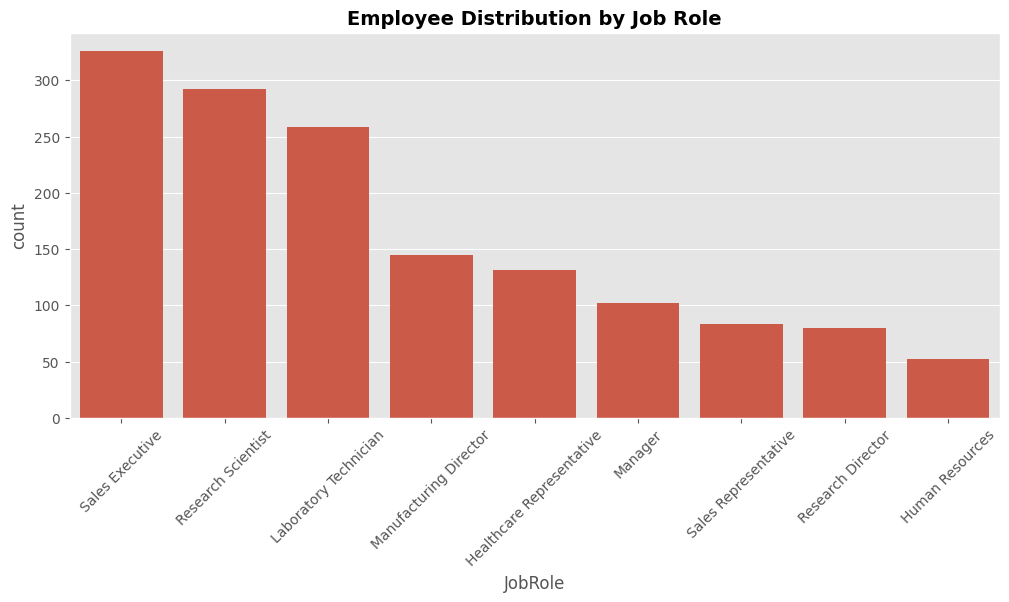

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="JobRole"
)

plt.title("Employee Distribution by Job Role",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=45)

plt.show()

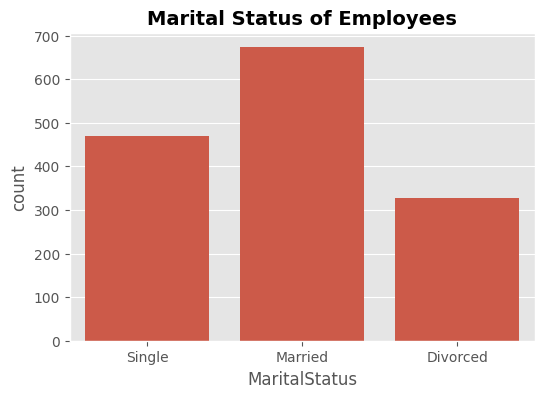

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="MaritalStatus"
)

plt.title("Marital Status of Employees",
          fontsize=14,
          fontweight="bold")

plt.show()

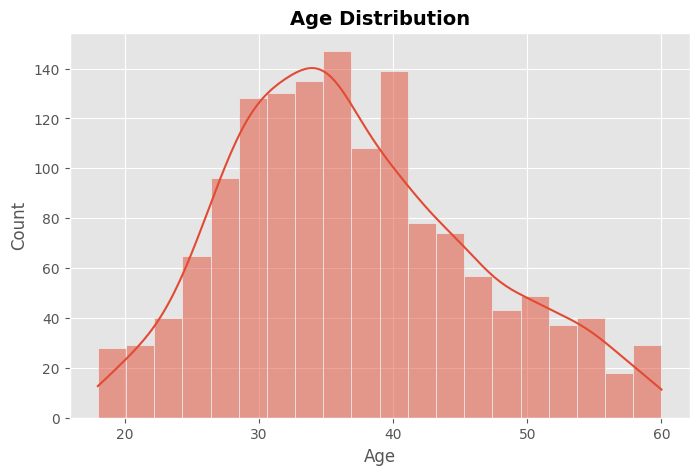

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Age")

plt.show()

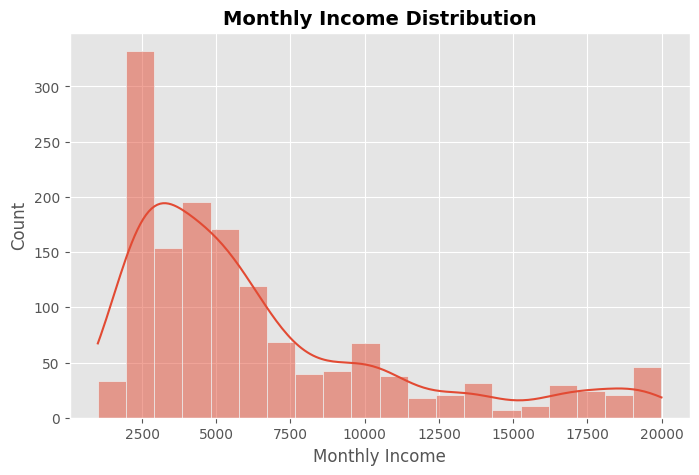

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyIncome"],
    bins=20,
    kde=True
)

plt.title("Monthly Income Distribution",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Monthly Income")

plt.show()

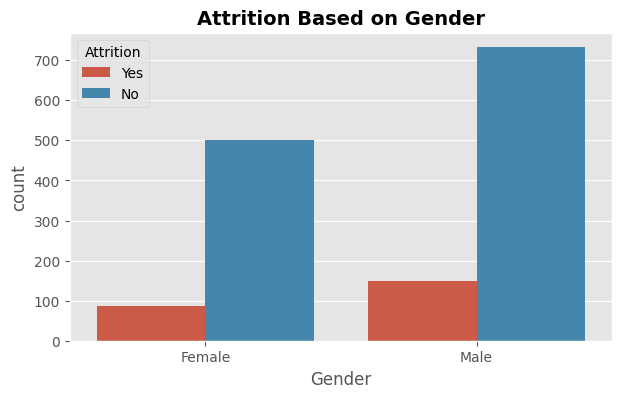

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Gender",
    hue="Attrition"
)

plt.title("Attrition Based on Gender",
          fontsize=14,
          fontweight="bold")

plt.show()

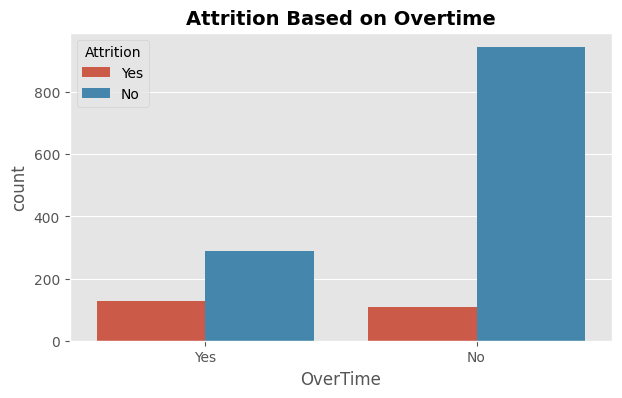

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("Attrition Based on Overtime",
          fontsize=14,
          fontweight="bold")

plt.show()

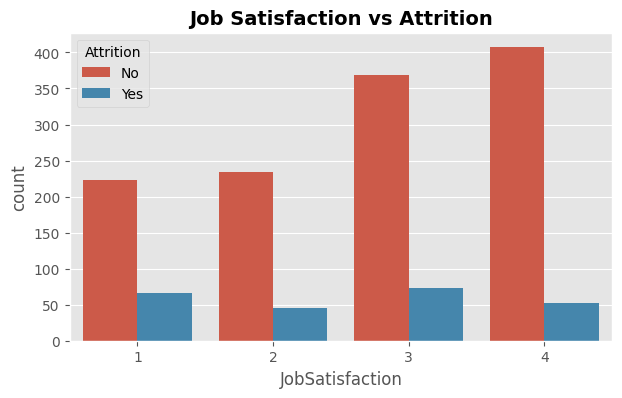

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title("Job Satisfaction vs Attrition",
          fontsize=14,
          fontweight="bold")

plt.show()

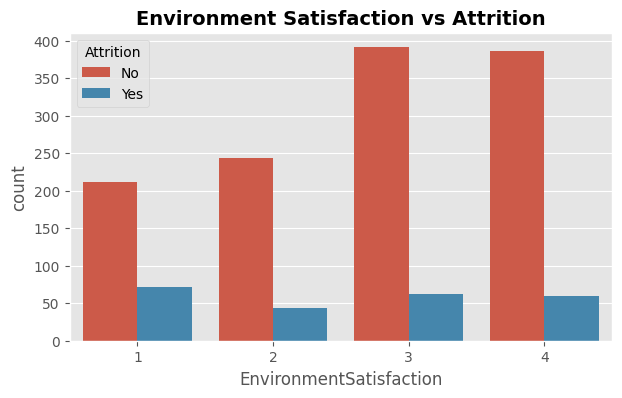

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="EnvironmentSatisfaction",
    hue="Attrition"
)

plt.title("Environment Satisfaction vs Attrition",
          fontsize=14,
          fontweight="bold")

plt.show()

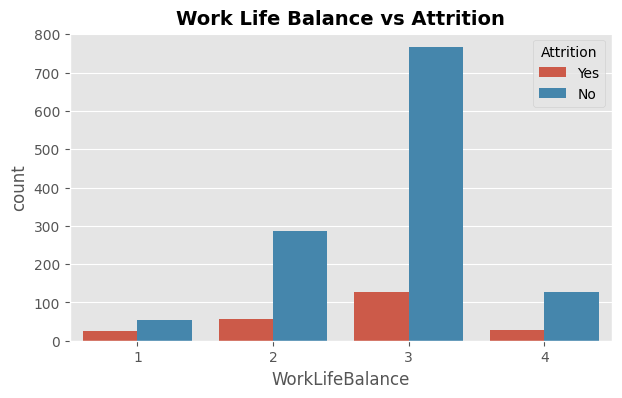

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work Life Balance vs Attrition",
          fontsize=14,
          fontweight="bold")

plt.show()

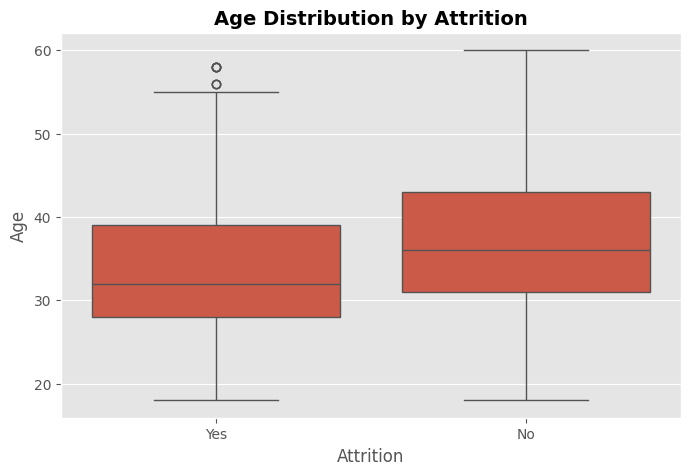

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Age Distribution by Attrition",
          fontsize=14,
          fontweight="bold")

plt.show()

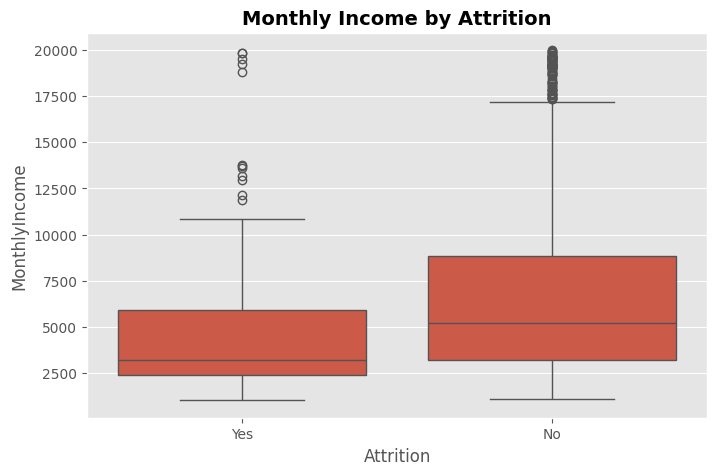

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition",
          fontsize=14,
          fontweight="bold")

plt.show()

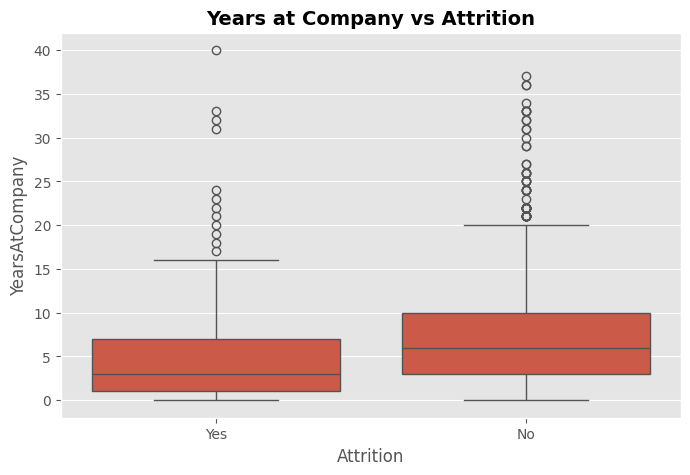

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company vs Attrition",
          fontsize=14,
          fontweight="bold")

plt.show()

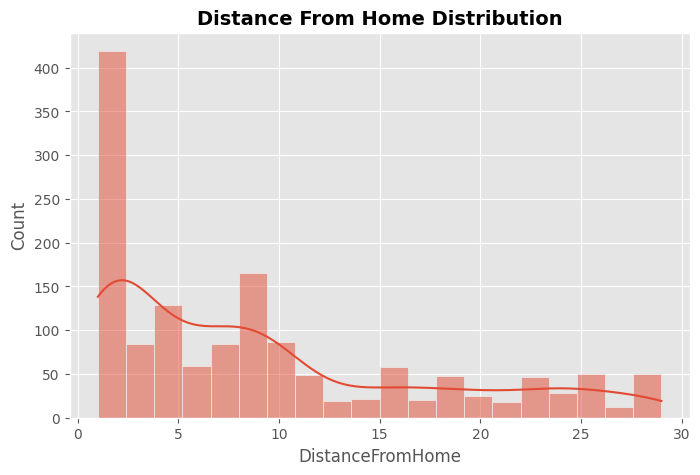

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["DistanceFromHome"],
    bins=20,
    kde=True
)

plt.title("Distance From Home Distribution",
          fontsize=14,
          fontweight="bold")

plt.show()

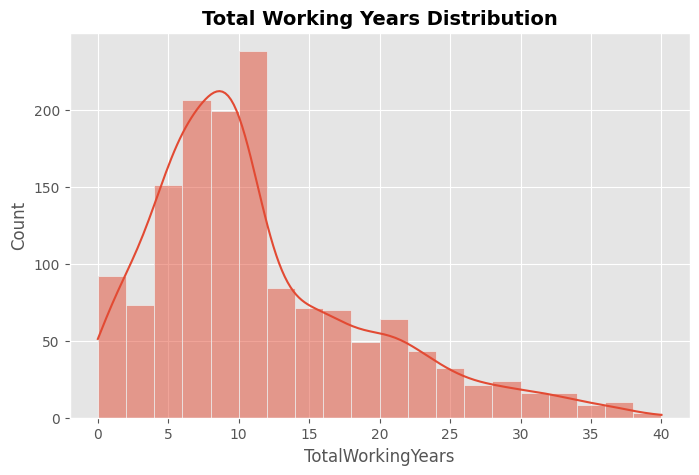

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["TotalWorkingYears"],
    bins=20,
    kde=True
)

plt.title("Total Working Years Distribution",
          fontsize=14,
          fontweight="bold")

plt.show()

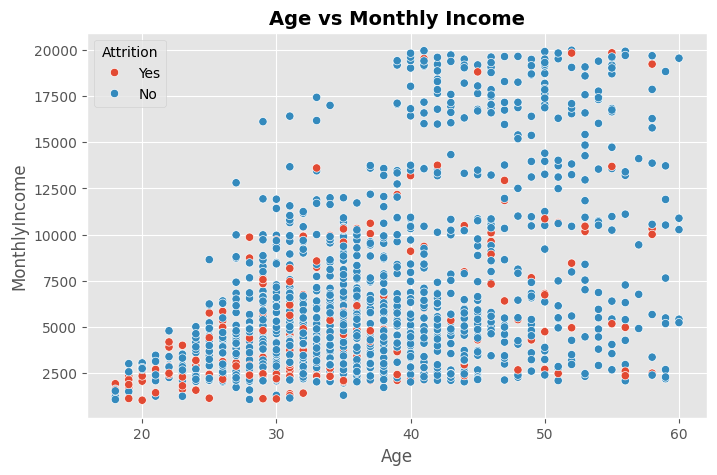

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="MonthlyIncome",
    hue="Attrition"
)

plt.title("Age vs Monthly Income",
          fontsize=14,
          fontweight="bold")

plt.show()

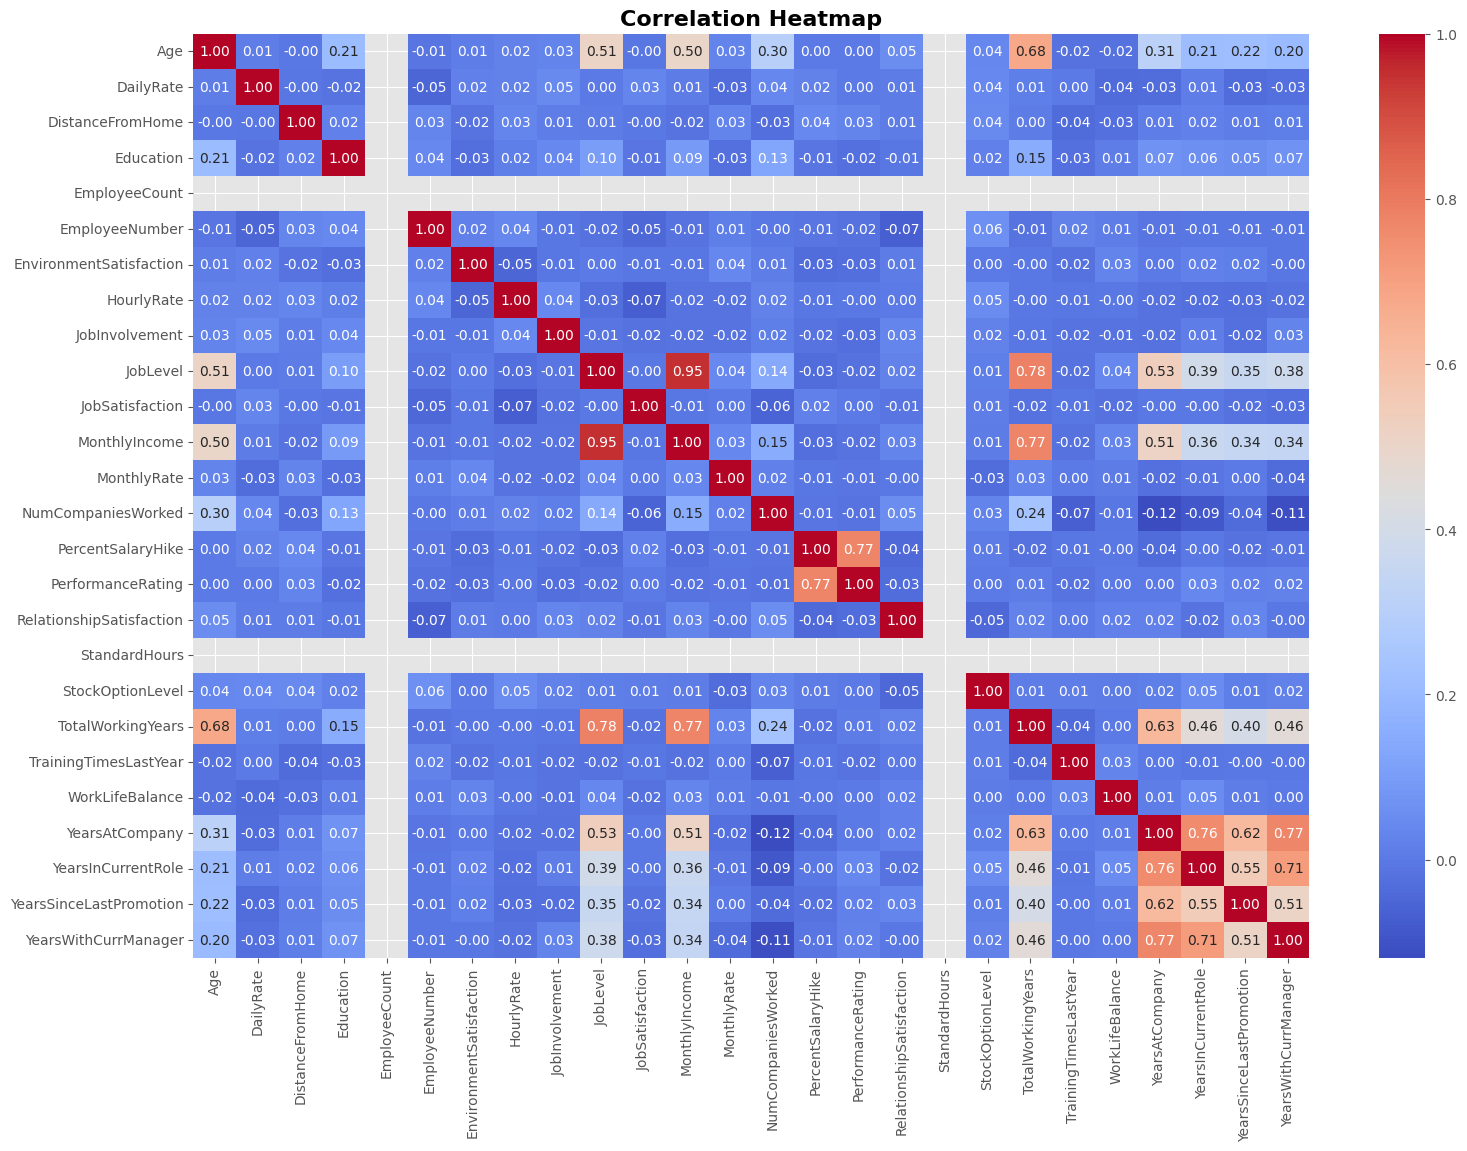

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(18,12))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap",
          fontsize=16,
          fontweight="bold")

plt.show()

In [ ]:
attrition_percentage = (
    df["Attrition"]
    .value_counts(normalize=True)
    *100
)

print("="*70)
print("ATTRITION PERCENTAGE")
print("="*70)

print(attrition_percentage)

ATTRITION PERCENTAGE
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [ ]:
print("\n" + "="*70)
print("DATASET INSIGHTS")
print("="*70)

print(f"Total Employees               : {len(df)}")

print(f"Employees Left Company        : {len(df[df['Attrition']=='Yes'])}")

print(f"Employees Stayed              : {len(df[df['Attrition']=='No'])}")

print(f"Average Age                  : {round(df['Age'].mean(),2)}")

print(f"Average Monthly Income       : {round(df['MonthlyIncome'].mean(),2)}")

print(f"Average Years At Company     : {round(df['YearsAtCompany'].mean(),2)}")

print(f"Average Total Working Years  : {round(df['TotalWorkingYears'].mean(),2)}")


DATASET INSIGHTS
Total Employees               : 1470
Employees Left Company        : 237
Employees Stayed              : 1233
Average Age                  : 36.92
Average Monthly Income       : 6502.93
Average Years At Company     : 7.01
Average Total Working Years  : 11.28


In [ ]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

print("="*70)
print("CATEGORICAL DATA ENCODED SUCCESSFULLY")
print("="*70)

CATEGORICAL DATA ENCODED SUCCESSFULLY


In [ ]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("="*70)
print("FEATURES")
print("="*70)

display(X.head())

print("="*70)
print("TARGET")
print("="*70)

display(y.head())

FEATURES


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,2,1102,2,1,2,1,1,1,2,...,1,80,0,8,0,1,6,4,0,5
1,49,1,279,1,8,1,1,1,2,3,...,4,80,1,10,3,3,10,7,1,7
2,37,2,1373,1,2,2,4,1,4,4,...,2,80,0,7,3,3,0,0,0,0
3,33,1,1392,1,3,4,1,1,5,4,...,3,80,0,8,3,3,8,7,3,0
4,27,2,591,1,2,1,3,1,7,1,...,4,80,1,6,3,3,2,2,2,2


TARGET


,Attrition
0,1
1,0
2,1
3,0
4,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("="*70)
print("TRAIN TEST SPLIT")
print("="*70)

print(f"Training Data : {X_train.shape}")

print(f"Testing Data  : {X_test.shape}")

TRAIN TEST SPLIT
Training Data : (1176, 34)
Testing Data  : (294, 34)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("="*70)
print("DATA SCALING COMPLETED")
print("="*70)

DATA SCALING COMPLETED


In [ ]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
print("="*70)
print("LOGISTIC REGRESSION MODEL CREATED")
print("="*70)

LOGISTIC REGRESSION MODEL CREATED


In [ ]:
model.fit(X_train, y_train)

print("="*70)
print("MODEL TRAINED SUCCESSFULLY")
print("="*70)

MODEL TRAINED SUCCESSFULLY


In [ ]:
y_pred = model.predict(X_test)

print("="*70)
print("PREDICTIONS GENERATED")
print("="*70)

PREDICTIONS GENERATED


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("="*70)
print("ACTUAL VS PREDICTED VALUES")
print("="*70)

display(comparison.head(10))

ACTUAL VS PREDICTED VALUES


,Actual,Predicted
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("="*70)
print("ACTUAL VS PREDICTED VALUES")
print("="*70)

display(comparison.head(10))

ACTUAL VS PREDICTED VALUES


,Actual,Predicted
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("="*70)
print("MODEL ACCURACY")
print("="*70)

print(f"Accuracy Score : {accuracy:.4f}")
print(f"Accuracy (%)   : {accuracy*100:.2f}%")

MODEL ACCURACY
Accuracy Score : 0.8912
Accuracy (%)   : 89.12%


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("="*70)
print("CONFUSION MATRIX")
print("="*70)

print(cm)

CONFUSION MATRIX
[[249   6]
 [ 26  13]]


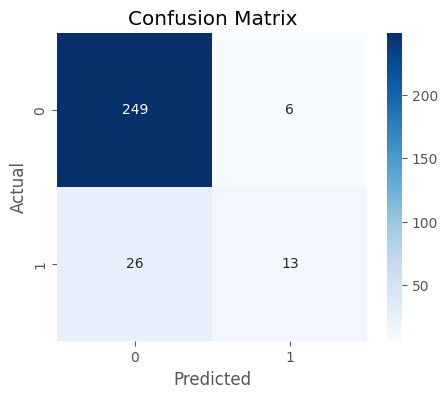

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print("="*70)
print("CLASSIFICATION REPORT")
print("="*70)

print(classification_report(y_test, y_pred))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.68      0.33      0.45        39

    accuracy                           0.89       294
   macro avg       0.79      0.65      0.69       294
weighted avg       0.88      0.89      0.87       294



In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("="*70)
print("ROC AUC SCORE")
print("="*70)
print(f"AUC Score : {auc:.4f}")

ROC AUC SCORE
AUC Score : 0.7721


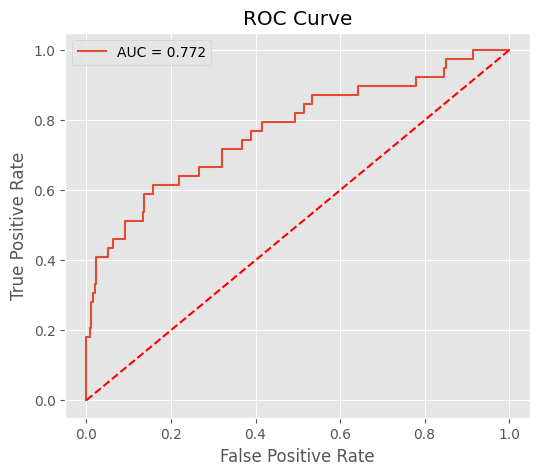

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Importance"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("="*70)
print("TOP 10 IMPORTANT FEATURES")
print("="*70)

display(feature_importance.head(10))

TOP 10 IMPORTANT FEATURES


,Feature,Coefficient,Importance
21,OverTime,0.868414,0.868414
30,YearsAtCompany,0.695904,0.695904
31,YearsInCurrentRole,-0.672363,0.672363
19,NumCompaniesWorked,0.468873,0.468873
32,YearsSinceLastPromotion,0.463748,0.463748
16,MaritalStatus,0.449013,0.449013
33,YearsWithCurrManager,-0.439423,0.439423
13,JobLevel,-0.430864,0.430864
15,JobSatisfaction,-0.409223,0.409223
3,Department,0.383758,0.383758


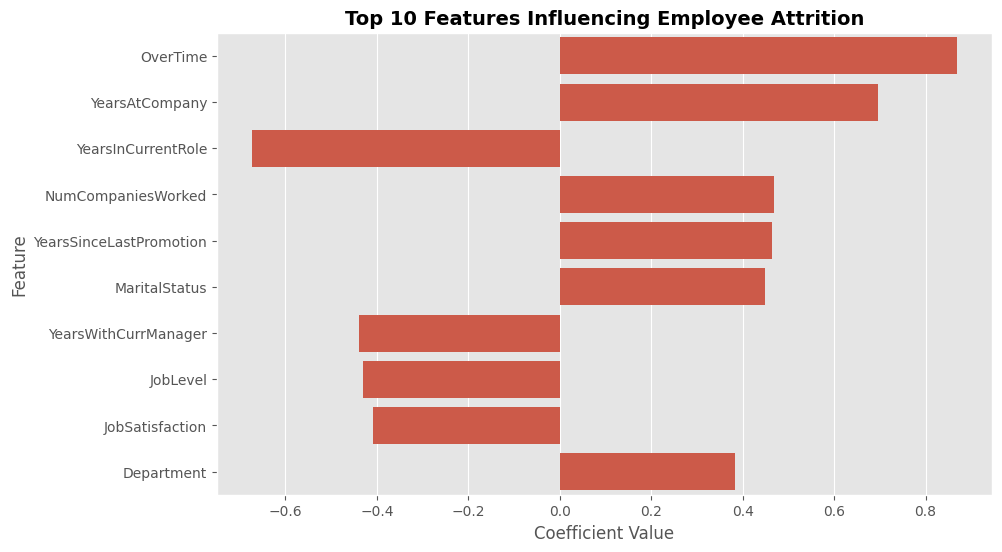

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Features Influencing Employee Attrition",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

In [ ]:
print("="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"Dataset Name        : IBM HR Employee Attrition Dataset")
print(f"Total Employees     : {len(df)}")
print(f"Total Features      : {len(df.columns)}")
print(f"Machine Learning    : Logistic Regression")
print(f"Target Variable     : Attrition")
print(f"Model Accuracy      : {accuracy*100:.2f}%")

PROJECT SUMMARY
Dataset Name        : IBM HR Employee Attrition Dataset
Total Employees     : 1470
Total Features      : 35
Machine Learning    : Logistic Regression
Target Variable     : Attrition
Model Accuracy      : 89.12%


In [ ]:
print("="*70)
print("CONCLUSION")
print("="*70)

print("""
The objective of this project was to analyze employee information and
predict whether an employee is likely to leave the company.

The dataset was explored using different EDA techniques to understand
the relationship between employee attributes and attrition.

After preprocessing the data, Logistic Regression was used to build
the prediction model.

The model was evaluated using Accuracy Score, Confusion Matrix and
Classification Report.

The results indicate that employee attrition can be predicted using
important factors such as overtime, monthly income, age, job role,
job satisfaction and years at the company.

This analysis can help HR departments identify employees who may leave
the organization and support better employee retention strategies.
""")

CONCLUSION

The objective of this project was to analyze employee information and
predict whether an employee is likely to leave the company.

The dataset was explored using different EDA techniques to understand
the relationship between employee attributes and attrition.

After preprocessing the data, Logistic Regression was used to build
the prediction model.

The model was evaluated using Accuracy Score, Confusion Matrix and
Classification Report.

The results indicate that employee attrition can be predicted using
important factors such as overtime, monthly income, age, job role,
job satisfaction and years at the company.

This analysis can help HR departments identify employees who may leave
the organization and support better employee retention strategies.



In [ ]:
print("="*70)
print("KEY INSIGHTS")
print("="*70)

print("""
• Most employees did not leave the company.

• Employees working overtime showed a higher tendency to leave.

• Job satisfaction and work-life balance have an impact on attrition.

• Monthly income and years at the company also influence employee retention.

• Logistic Regression achieved good prediction accuracy on this dataset.

• HR departments can use these insights to improve employee satisfaction
  and reduce attrition.
""")

KEY INSIGHTS

• Most employees did not leave the company.

• Employees working overtime showed a higher tendency to leave.

• Job satisfaction and work-life balance have an impact on attrition.

• Monthly income and years at the company also influence employee retention.

• Logistic Regression achieved good prediction accuracy on this dataset.

• HR departments can use these insights to improve employee satisfaction
  and reduce attrition.



In [ ]:
print("="*70)
print("END OF PROJECT")
print("="*70)

print("""
Employee Attrition Prediction using Machine Learning

Developed using:
• Python
• Pandas
• NumPy
• Matplotlib
• Seaborn
• Scikit-learn

Thank You!
""")

END OF PROJECT

Employee Attrition Prediction using Machine Learning

Developed using:
• Python
• Pandas
• NumPy
• Matplotlib
• Seaborn
• Scikit-learn

Thank You!

